# 4. HybridRAG and Ablation Evaluation: VectorRAG vs GraphRAG vs HybridRAG

**Part of the AlzRAGBench notebook series** (`Diffusion_AlzRAGBench_v2.0/`) -- the
final notebook, which ties Notebooks 1-3 together into a controlled comparison.

**Requires a GPU with roughly >=8GB VRAM.** This notebook loads the same SDLM-3B-D4
diffusion LLM used in Notebooks 2 and 3 (plain bf16, no quantization needed), and runs
it **90 times** (30 questions x 3 methods) -- expect this notebook to take
substantially longer to run end-to-end than Notebooks 2 or 3. A "quick test" mode
(Section 4.8) lets you sanity-check the whole pipeline on 3 questions before
committing to the full run.

## What this notebook builds

This notebook is entirely self-contained: it rebuilds both the GraphRAG pipeline
(Notebook 2) and the VectorRAG pipeline (Notebook 3) from scratch, condensed to their
essential retrieval functions (skipping the exploratory demonstrations already covered
in those notebooks), then:

1. Defines a **HybridRAG** pipeline: retrieve from *both* the vector index and the
   knowledge graph, merge both into one prompt, generate one answer.
2. Runs **all three** methods (VectorRAG, GraphRAG, HybridRAG) against every question in
   `../Dataset/Evaluation/eval_dataset.json` -- the 30-question set built specifically
   for this ablation, split evenly into questions designed to favor each method.
3. Scores every generated answer against the gold `expected_answer` using automatic
   text-similarity metrics (ROUGE-L + embedding cosine similarity) -- fast and fully
   reproducible, with no extra LLM-as-judge calls needed.
4. Additionally scores **retrieval quality directly** (not just final-answer quality),
   using the eval set's `supporting_sources` and `reasoning_path` ground-truth fields:
   did VectorRAG's top-k chunks actually come from the right articles? Did GraphRAG's
   retrieved subgraph actually touch the right entities?
5. Aggregates results by each question's `designed_to_favor` label and visualizes
   whether each method actually wins on the question type it was hypothesized to.

## 4.1 Install dependencies


In [ ]:
# !pip install -q torch "transformers==4.37.2" accelerate sentence-transformers numpy pandas networkx rouge-score tqdm matplotlib

## 4.2 Imports, paths, and GPU check


In [1]:
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import json
import time
from pathlib import Path

import networkx as nx
import numpy as np
import pandas as pd
import torch
from sentence_transformers import SentenceTransformer, util
from tqdm.auto import tqdm

DATASET_DIR = Path("Dataset")
KG_DIR = DATASET_DIR / "Knowledge graph"
CHUNKS_PATH = DATASET_DIR / "chunking" / "_all_chunks.json"
EVAL_PATH = DATASET_DIR / "Evaluation" / "eval_dataset.json"
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  ({props.total_memory / 1e9:.1f} GB VRAM)")
else:
    print("WARNING: no CUDA GPU detected. Retrieval setup (4.3-4.5) will still run, "
          "but generation (4.6 onward) requires a GPU with roughly >=8GB VRAM.")

eval_data = json.load(open(EVAL_PATH, encoding="utf-8"))
print(f"Loaded {len(eval_data['questions'])} evaluation questions "
      f"(distribution: {eval_data['distribution_by_target_method']})")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


GPU: Tesla T4  (15.6 GB VRAM)
Loaded 30 evaluation questions (distribution: {'vectorrag': 10, 'graphrag': 10, 'hybridrag': 10})


## 4.3 Rebuild GraphRAG components (condensed from Notebook 2)

Same graph construction, entity linking, and retrieval logic as Notebook 2 -- see that
notebook for the full walkthrough and rationale of each piece. Here we collapse the
four individually-demonstrated retrieval strategies into one **`graph_retrieve_auto`**
function that a real system would use without a human picking a strategy per question:

- **0 linked entities** -> fall back to centrality-guided global context.
- **1 linked entity** -> hub-avoiding multi-hop expansion from that entity.
- **2+ linked entities** -> multi-hop expansion from all of them, *plus* the explicit
  shortest path between the first two (to make sure the direct connecting chain, if
  one exists, is never left out).


In [2]:
import re

nodes_df = pd.read_csv(KG_DIR / "nodes.csv")
edges_df = pd.read_csv(KG_DIR / "edges.csv")

G = nx.MultiDiGraph()
for _, row in nodes_df.iterrows():
    G.add_node(row["nodeId:ID"], name=row["name"], type=row["type:LABEL"], description=row["description"])
for _, row in edges_df.iterrows():
    G.add_edge(row[":START_ID"], row[":END_ID"], relation=row[":TYPE"],
               source_articles=row["source_articles"], evidence=row["evidence"])

degree_centrality = nx.degree_centrality(G.to_undirected())
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph: 54 nodes, 89 edges


In [3]:
MANUAL_ALIASES = {
    "AD": ["ad", "alzheimer's disease", "alzheimer disease", "alzheimers"],
    "MCI": ["mci", "mild cognitive impairment"],
    "APOE_e4": ["apoe4", "apoe e4", "apoe epsilon-4", "epsilon-4", "e4 allele"],
    "APOE_e2": ["apoe2", "apoe e2", "apoe epsilon-2", "epsilon-2", "e2 allele"],
    "AmyloidBeta": ["amyloid-beta", "amyloid beta", "abeta", "a-beta"],
    "NFT": ["neurofibrillary tangles", "tangles", "nft"],
    "ARIA": ["aria", "amyloid-related imaging abnormalities"],
    "APP": ["app gene", "amyloid precursor protein", "app"],
    "DownSyndrome": ["down syndrome", "trisomy 21"],
    "AntiAmyloidAntibodies": ["anti-amyloid", "monoclonal antibodies", "anti-amyloid antibodies"],
    "CholinesteraseInhibitors": ["cholinesterase inhibitor", "cholinesterase inhibitors", "chei"],
    "GlymphaticSystem": ["glymphatic", "glymphatic system"],
    "NMDAReceptor": ["nmda receptor", "nmda"],
    "FluidBiomarkers": ["csf biomarkers", "plasma biomarkers", "abeta42/40"],
    "MRIAtrophy": ["mri", "structural mri", "brain atrophy"],
    "AmyloidPET": ["amyloid pet"],
    "TauPET": ["tau pet"],
    "CardiovascularRisk": ["vascular risk factors", "cardiovascular risk factors", "vascular risk"],
    "VascularDementia": ["vascular dementia"],
    "MixedDementia": ["mixed dementia"],
    "SexDifferences": ["sex differences", "gender differences", "sex and gender"],
    "AmyloidCascadeHypothesis": ["amyloid cascade hypothesis", "amyloid hypothesis"],
    "SleepDisturbance": ["poor sleep", "sleep disturbance", "sleep"],
    "Aging": ["aging", "ageing"],
}


def build_alias_index(G):
    alias_to_node = {}

    def register(alias, node_id):
        alias = alias.lower().strip()
        if len(alias) < 3:
            return
        alias_to_node.setdefault(alias, node_id)

    for node_id, data in G.nodes(data=True):
        register(node_id, node_id)
        register(data["name"], node_id)
        spaced = re.sub(r"(?<!^)(?=[A-Z])", " ", node_id).lower()
        register(spaced, node_id)
        no_parens = re.sub(r"\s*\([^)]*\)", "", data["name"])
        register(no_parens, node_id)

    for node_id, aliases in MANUAL_ALIASES.items():
        for a in aliases:
            register(a, node_id)
    return alias_to_node


ALIAS_INDEX = build_alias_index(G)
SORTED_ALIASES = sorted(ALIAS_INDEX.keys(), key=len, reverse=True)


def link_entities(question, max_entities=6):
    q = question.lower()
    found, covered_spans = [], []

    def overlaps(start, end):
        return any(not (end <= s or start >= e) for s, e in covered_spans)

    for alias in SORTED_ALIASES:
        pattern = r"(?<![a-z0-9])" + re.escape(alias) + r"(?![a-z0-9])"
        for m in re.finditer(pattern, q):
            if overlaps(m.start(), m.end()):
                continue
            node_id = ALIAS_INDEX[alias]
            if node_id not in found:
                found.append(node_id)
            covered_spans.append((m.start(), m.end()))
    return found[:max_entities]


def filter_dominant_hubs(entities, degree_centrality, threshold=0.3):
    non_hub = [e for e in entities if degree_centrality.get(e, 0) <= threshold]
    return non_hub if non_hub else entities


print(f"Built alias index with {len(ALIAS_INDEX)} aliases.")


Built alias index with 164 aliases.


In [4]:
def edge_record(u, v, data):
    return {
        "start": u, "end": v,
        "start_name": G.nodes[u]["name"], "end_name": G.nodes[v]["name"],
        "relation": data["relation"], "evidence": data["evidence"],
        "source_articles": data["source_articles"],
    }


def dedupe_edges(edges):
    seen, out = set(), []
    for e in edges:
        key = (e["start"], e["end"], e["relation"])
        if key not in seen:
            seen.add(key)
            out.append(e)
    return out


def retrieve_multihop(entities, G, degree_centrality, max_hops=2, hub_threshold=0.3):
    visited = set(e for e in entities if e in G)
    frontier = set(visited)
    all_edges, seen = [], set()
    for _ in range(max_hops):
        next_frontier = set()
        for node in frontier:
            is_hub = degree_centrality.get(node, 0) > hub_threshold
            for _, v, data in G.out_edges(node, data=True):
                key = (node, v, data["relation"])
                if key not in seen:
                    seen.add(key)
                    all_edges.append(edge_record(node, v, data))
                if v not in visited and not is_hub:
                    next_frontier.add(v)
            for u, _, data in G.in_edges(node, data=True):
                key = (u, node, data["relation"])
                if key not in seen:
                    seen.add(key)
                    all_edges.append(edge_record(u, node, data))
                if u not in visited and not is_hub:
                    next_frontier.add(u)
        visited |= next_frontier
        frontier = next_frontier
        if not frontier:
            break
    return all_edges, visited


def retrieve_shortest_path(entity_a, entity_b, G):
    undirected = G.to_undirected()
    try:
        path = nx.shortest_path(undirected, entity_a, entity_b)
    except (nx.NetworkXNoPath, nx.NodeNotFound):
        return None
    edges = []
    for u, v in zip(path[:-1], path[1:]):
        if G.has_edge(u, v):
            data = next(iter(G.get_edge_data(u, v).values()))
            edges.append(edge_record(u, v, data))
        elif G.has_edge(v, u):
            data = next(iter(G.get_edge_data(v, u).values()))
            edges.append(edge_record(v, u, data))
    return {"path": path, "edges": edges}


def retrieve_global_context(G, degree_centrality, top_k=10):
    top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:top_k]
    top_ids = {n for n, _ in top_nodes}
    edges, seen = [], set()
    for u, v, data in G.edges(data=True):
        if u in top_ids and v in top_ids:
            key = (u, v, data["relation"])
            if key not in seen:
                seen.add(key)
                edges.append(edge_record(u, v, data))
    return edges


def graph_retrieve_auto(question, max_hops=2):
    """Routes to the retrieval strategy appropriate for how many entities we could
    link, so the ablation loop doesn't need a human picking a strategy per question."""
    entities = filter_dominant_hubs(link_entities(question), degree_centrality)
    if not entities:
        return retrieve_global_context(G, degree_centrality, top_k=10), entities
    edges, _ = retrieve_multihop(entities, G, degree_centrality, max_hops=max_hops)
    if len(entities) >= 2:
        sp = retrieve_shortest_path(entities[0], entities[1], G)
        if sp:
            existing = {(e["start"], e["end"], e["relation"]) for e in edges}
            for e in sp["edges"]:
                if (e["start"], e["end"], e["relation"]) not in existing:
                    edges.append(e)
    return dedupe_edges(edges), entities


def format_graph_context(edges, limit=15):
    lines = [
        f"- {e['start_name']} --[{e['relation']}]--> {e['end_name']}: {e['evidence']} (source: {e['source_articles']})"
        for e in edges[:limit]
    ]
    return "\n".join(lines)


## 4.4 Rebuild VectorRAG components (condensed from Notebook 3)


In [5]:
chunks = json.load(open(CHUNKS_PATH, encoding="utf-8"))
chunk_texts = [c["text"] for c in chunks]

EMBED_MODEL_ID = "NeuML/pubmedbert-base-embeddings"
embed_model = SentenceTransformer(EMBED_MODEL_ID, device="cuda" if torch.cuda.is_available() else "cpu")

chunk_embeddings = embed_model.encode(
    chunk_texts, batch_size=32, show_progress_bar=True,
    convert_to_numpy=True, normalize_embeddings=True,
)
print(f"Embedded {len(chunks)} chunks -> {chunk_embeddings.shape}")


def vector_search(query, k=5):
    q_emb = embed_model.encode([query], convert_to_numpy=True, normalize_embeddings=True)[0]
    sims = chunk_embeddings @ q_emb
    top_idx = np.argsort(-sims)[:k]
    return [{**chunks[i], "score": float(sims[i])} for i in top_idx]


def format_vector_context(retrieved_chunks):
    return "\n\n".join(f"[Passage from {r['article_id']}]\n{r['text']}" for r in retrieved_chunks)


/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Embedded 287 chunks -> (287, 768)


## 4.5 Retrieval-quality diagnostics (using the eval set's ground truth)

Beyond scoring the *final generated answer*, we can directly check whether each
retrieval method found the right underlying material, using two ground-truth fields
already built into `eval_dataset.json`:

- `supporting_sources`: the `article_id`s the gold answer is actually grounded in --
  compare against which `article_id`s VectorRAG's top-k chunks came from.
- `reasoning_path`: the knowledge-graph node IDs relevant to the question -- compare
  against which nodes GraphRAG's retrieved edges actually touched.

This separates two very different failure modes that final-answer text-similarity
metrics alone would blur together: **retrieval failure** (found the wrong material) vs.
**generation failure** (found the right material but the LLM didn't use it well).


In [6]:
def vector_retrieval_hit_rate(retrieved_chunks, supporting_sources):
    if not supporting_sources:
        return None
    retrieved_articles = {r["article_id"] for r in retrieved_chunks}
    hits = retrieved_articles & set(supporting_sources)
    return len(hits) / len(set(supporting_sources))


def graph_retrieval_hit_rate(edges, reasoning_path):
    if not reasoning_path:
        return None
    touched_nodes = set()
    for e in edges:
        touched_nodes.add(e["start"])
        touched_nodes.add(e["end"])
    hits = touched_nodes & set(reasoning_path)
    return len(hits) / len(set(reasoning_path))


## 4.6 Load SDLM-3B-D4 once (shared across all three methods, reloaded periodically)

Loaded once here and reused for VectorRAG, GraphRAG, and HybridRAG generation. Section
4.9's full 90-generation run also reloads the model fresh every `RELOAD_EVERY`
generations as a safety net on top of the per-call VRAM cleanup baked into
`generate_with_sdlm` (Notebook 2, Section 2.10) -- cheap insurance against a long
unattended run, at the cost of a brief reload pause every so often.

See Notebook 2, Section 2.9, for a `flash_attn` `ImportError` you may hit here even with `attn_implementation="eager"` -- it's a `transformers` import-scanner false-positive, not an actual flash_attn requirement; `load_sdlm()` below works around it.

In [7]:
import gc
from unittest.mock import patch as _mock_patch

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.dynamic_module_utils import get_imports

SDLM_MODEL_ID = "OpenGVLab/SDLM-3B-D4"


def _skip_flash_attn_check(filename):
    """See Notebook 2, Section 2.9, for why this is needed: modeling_sdlm.py's
    flash_attn import is guarded by `if is_flash_attn_2_available():`, but
    transformers' import scanner doesn't understand if-guards (only try/except) and
    flags flash_attn as required anyway, even though attn_implementation="eager"
    never touches that code path (github.com/huggingface/transformers/issues/28459)."""
    imports = get_imports(filename)
    if str(filename).endswith("modeling_sdlm.py") and "flash_attn" in imports:
        imports.remove("flash_attn")
    return imports


def load_sdlm():
    """Fresh tokenizer + model load. Used once up front and then again periodically
    during the full 90-generation run (Section 4.9) as a VRAM safety net -- see the
    markdown above and Notebook 2's Section 2.10 for the underlying per-call cleanup
    this reload strategy sits on top of."""
    with _mock_patch("transformers.dynamic_module_utils.get_imports", _skip_flash_attn_check):
        tok = AutoTokenizer.from_pretrained(SDLM_MODEL_ID, trust_remote_code=True)
        mdl = AutoModelForCausalLM.from_pretrained(
            SDLM_MODEL_ID,
            trust_remote_code=True,
            attn_implementation="eager",
            torch_dtype=torch.bfloat16,
        )
    mdl = mdl.to("cuda" if torch.cuda.is_available() else "cpu")
    mdl.eval()
    return tok, mdl


tokenizer, model = load_sdlm()
print(f"Loaded {SDLM_MODEL_ID}")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded OpenGVLab/SDLM-3B-D4
GPU memory allocated: 7.22 GB


In [8]:
import gc

import torch
import torch.nn.functional as F


def _top_p_logits(logits, top_p):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
    sorted_indices_to_remove = cumulative_probs > top_p
    sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
    sorted_indices_to_remove[..., 0] = 0
    mask = torch.zeros_like(logits, dtype=torch.bool).scatter_(-1, sorted_indices, sorted_indices_to_remove)
    return logits.masked_fill(mask, torch.finfo(logits.dtype).min)


def _sample_tokens(logits, temperature=0.0, top_p=None, entropy_conf=False):
    """Returns (confidence, token_id) for each of the n_future_tokens candidate
    positions. Confidence is either top-probability (used to decide how many of the
    candidate tokens to "accept" this step) or a normalized-entropy score."""
    if temperature > 0:
        logits = logits / temperature
    if top_p is not None and top_p < 1:
        logits = _top_p_logits(logits, top_p)
    probs = torch.softmax(logits, dim=-1)

    if temperature > 0:
        x0 = torch.distributions.Categorical(probs=probs).sample()
        confidence = torch.gather(probs, -1, x0.unsqueeze(-1)).squeeze(-1)
    else:
        confidence, x0 = probs.max(dim=-1)

    if entropy_conf:
        entropy = -torch.sum(probs * torch.log(probs + 1e-9), dim=-1)
        max_entropy = torch.log(torch.tensor(float(probs.shape[-1]), device=entropy.device))
        confidence = 1.0 - (entropy / max_entropy)

    return confidence, x0


def _find_accept_length(confidence, threshold):
    """How many of the n_future_tokens candidate tokens (in order) are confident
    enough to commit this step -- SDLM accepts the longest confident *prefix*, since
    later candidate positions were predicted assuming all earlier ones land correctly."""
    mask = confidence > threshold
    first_low_confidence = torch.argmax((~mask).int(), dim=1)
    all_confident = mask.all(dim=1)
    seq_len = confidence.shape[1]
    return torch.where(all_confident, torch.full_like(first_low_confidence, seq_len), first_low_confidence)


@torch.no_grad()
def sdlm_generate(model, tokenizer, input_ids, max_gen_len=192, threshold=0.5,
                   n_future_tokens=4, temperature=0.0, top_p=None, alg="prob_conf"):
    """Semi-autoregressive block-diffusion generation with KV-cache reuse. Adapted from
    OpenGVLab's official SDLM_generate (github.com/OpenGVLab/SDLM), trimmed to the
    prob_conf/entropy_conf paths, with explicit intermediate-tensor cleanup added each
    iteration (see Section 2.10 markdown for why that matters).

    At each step: append n_future_tokens mask-token placeholders after the current
    sequence, run one forward pass reusing the cached keys/values from previous steps,
    and predict all n_future_tokens positions at once. Accept however many of those (in
    order, starting from the first) the model is confident enough about, roll the KV
    cache back to just past the accepted tokens, and repeat.
    """
    device = model.device
    mask_token_id = getattr(model.config, "text_mask_token_id", 151665)
    eos_ids = set(tokenizer.eos_token_id) if isinstance(tokenizer.eos_token_id, (list, tuple)) else {tokenizer.eos_token_id}
    gen_eos = getattr(model.generation_config, "eos_token_id", None)
    if gen_eos is not None:
        eos_ids |= set(gen_eos) if isinstance(gen_eos, (list, tuple)) else {gen_eos}

    model.model.block_size = getattr(model.config, "block_size", n_future_tokens)
    model.model.causal_attn = getattr(model.config, "causal_attn", False)
    model.model.text_mask_token_id = mask_token_id
    model.use_cache = True

    generated = input_ids.clone()
    prompt_len = generated.shape[1]
    target_len = prompt_len + max_gen_len
    past_key_values = None

    while generated.shape[1] < target_len:
        mask_tokens = torch.full((1, n_future_tokens - 1), mask_token_id, dtype=generated.dtype, device=device)
        generated_with_mask = torch.cat([generated, generated[:, -1:], mask_tokens], dim=1)

        start_idx = past_key_values[0][0].shape[2] if past_key_values is not None else 0
        position_ids = torch.arange(start_idx, generated_with_mask.shape[1], device=device).unsqueeze(0)
        position_ids[0, -n_future_tokens:] -= 1

        model_inputs = model.prepare_inputs_for_generation(
            generated_with_mask, past_key_values, None, use_cache=True, position_ids=position_ids,
        )
        outputs = model(**model_inputs)

        logits = outputs.logits[:, -n_future_tokens:, :]
        confidence, x0 = _sample_tokens(logits, temperature=temperature, top_p=top_p, entropy_conf=(alg == "entropy_conf"))
        accept_len = max(1, min(int(_find_accept_length(confidence, threshold)[0].item()), n_future_tokens))

        new_tokens = x0[0, :accept_len]
        eos_pos = next((i for i, t in enumerate(new_tokens.tolist()) if t in eos_ids), None)
        if eos_pos is not None:
            new_tokens = new_tokens[:eos_pos]

        generated = torch.cat([generated, new_tokens.unsqueeze(0)], dim=1)

        # Roll the KV cache back to only the tokens actually committed this step --
        # this, plus the cleanup below, is what keeps VRAM flat across many calls
        # instead of creeping upward the way the previous (LLaDA) notebook's
        # full-resequence-every-step approach did.
        past_key_values = tuple(
            (k[:, :, : generated.shape[1], :], v[:, :, : generated.shape[1], :])
            for k, v in outputs.past_key_values
        )
        del outputs, logits, confidence, x0, generated_with_mask, model_inputs

        if eos_pos is not None:
            break

    return generated[:, prompt_len:]


def generate_with_sdlm(prompt_text, system_prompt=None, max_gen_len=128, threshold=0.5,
                        n_future_tokens=4, temperature=0.0):
    """High-level helper: apply the chat template, run sdlm_generate, decode the
    response, and release GPU memory before returning -- see Section 2.10."""
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt_text})

    formatted = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    input_ids = tokenizer([formatted], return_tensors="pt").input_ids.to(model.device)

    response_ids = sdlm_generate(
        model, tokenizer, input_ids,
        max_gen_len=max_gen_len, threshold=threshold, n_future_tokens=n_future_tokens, temperature=temperature,
    )
    answer = tokenizer.decode(response_ids[0], skip_special_tokens=True).strip()

    del input_ids, response_ids
    gc.collect()
    torch.cuda.empty_cache()

    return answer

## 4.7 The three RAG pipelines, side by side

`hybridrag_answer` is the only genuinely new piece here: it retrieves from *both*
indexes independently, then concatenates both context blocks (clearly labeled) into a
single prompt before generating one answer -- the simplest possible fusion strategy,
letting the LLM itself weigh which retrieved evidence to rely on.


In [9]:
VECTOR_SYSTEM_PROMPT = (
    "You are a biomedical question-answering assistant. Answer the user's question "
    "using only the retrieved passages provided. Be concise and directly address "
    "the question."
)
GRAPH_SYSTEM_PROMPT = (
    "You are a biomedical question-answering assistant. Answer the user's question "
    "using only the retrieved knowledge-graph facts provided. Be concise and "
    "directly address the question."
)
HYBRID_SYSTEM_PROMPT = (
    "You are a biomedical question-answering assistant. You are given both text "
    "passages and knowledge-graph facts retrieved for this question. Use whichever "
    "evidence (or combination) best answers the question. Be concise and directly "
    "address the question."
)


def vectorrag_answer(question, k=5):
    retrieved = vector_search(question, k=k)
    prompt = f"Retrieved passages:\n{format_vector_context(retrieved)}\n\nQuestion: {question}"
    answer = generate_with_sdlm(prompt, system_prompt=VECTOR_SYSTEM_PROMPT)
    return {"answer": answer, "vector_retrieved": retrieved, "graph_edges": [], "linked_entities": []}


def graphrag_answer(question):
    edges, entities = graph_retrieve_auto(question)
    prompt = f"Knowledge graph facts:\n{format_graph_context(edges)}\n\nQuestion: {question}"
    answer = generate_with_sdlm(prompt, system_prompt=GRAPH_SYSTEM_PROMPT)
    return {"answer": answer, "vector_retrieved": [], "graph_edges": edges, "linked_entities": entities}


def hybridrag_answer(question, k=5):
    retrieved = vector_search(question, k=k)
    edges, entities = graph_retrieve_auto(question)
    prompt = (
        f"Retrieved text passages:\n{format_vector_context(retrieved)}\n\n"
        f"Retrieved knowledge graph facts:\n{format_graph_context(edges)}\n\n"
        f"Question: {question}"
    )
    answer = generate_with_sdlm(prompt, system_prompt=HYBRID_SYSTEM_PROMPT)
    return {"answer": answer, "vector_retrieved": retrieved, "graph_edges": edges, "linked_entities": entities}


ANSWER_FUNCTIONS = {
    "vectorrag": vectorrag_answer,
    "graphrag": graphrag_answer,
    "hybridrag": hybridrag_answer,
}

## 4.8 Quick test: 3 questions, all 3 methods

Before committing to the full 90-generation run (which will take a while), sanity
check the whole pipeline end-to-end on a small sample.


In [10]:
sample_questions = eval_data["questions"][:3]

for q in sample_questions:
    print("=" * 100)
    print(f"[{q['question_id']}] {q['question']}  (favors: {q['designed_to_favor']})")
    for method_name, fn in ANSWER_FUNCTIONS.items():
        t0 = time.time()
        result = fn(q["question"])
        elapsed = time.time() - t0
        print(f"\n  [{method_name}] ({elapsed:.1f}s): {result['answer'][:300]}")
    print(f"\n  Gold: {q['expected_answer'][:300]}")


[q01] What is the strongest genetic risk factor for sporadic Alzheimer's disease?  (favors: vectorrag)

  [vectorrag] (5.5s): The strongest genetic risk factor for sporadic Alzheimer's disease disease is APOEε4.

  [graphrag] (3.8s): APO strongestE epsilon-4 allele (APOEE) is the strongest genetic risk factor for sporadic Alzheimer's disease.

  [hybridrag] (7.5s): APO strongestEpsilon-4 allele

  Gold: The APOE epsilon-4 (e4) allele is the strongest genetic risk factor for sporadic Alzheimer's disease, confirmed by large-scale GWAS meta-analyses.
[q02] What is the strongest genetic protective factor against Alzheimer's disease?  (favors: vectorrag)

  [vectorrag] (5.3s): APO strongest genetic protective factor against Alzheimer's disease is APOE2 allele.

  [graphrag] (3.6s): APO strongestE epsilon-2 allele (APOEE) is the strongest genetic protective factor against Alzheimer's disease.

  [hybridrag] (7.0s): APOE epsilon-2 allele

  Gold: The APOE epsilon-2 (e2) allele is the stronges

## 4.9 Full run: all 30 questions x 3 methods

This runs `vectorrag_answer`, `graphrag_answer`, and `hybridrag_answer` on every
question in the eval set (90 generations total) and saves the raw results to
`artifacts/raw_results.json` as it goes, so a crash partway through doesn't lose
already-completed work.


In [11]:
raw_results_path = ARTIFACTS_DIR / "raw_results.json"
raw_results = []

if raw_results_path.exists():
    raw_results = json.load(open(raw_results_path, encoding="utf-8"))
    done_keys = {(r["question_id"], r["method"]) for r in raw_results}
    print(f"Resuming: {len(raw_results)} results already saved from a previous run.")
else:
    done_keys = set()

RELOAD_EVERY = 15  # reload the model fresh every N generations, as a safety net on top of per-call cleanup
generations_since_reload = 0

for q in tqdm(eval_data["questions"], desc="questions"):
    for method_name, fn in ANSWER_FUNCTIONS.items():
        if (q["question_id"], method_name) in done_keys:
            continue

        if generations_since_reload >= RELOAD_EVERY:
            del model
            gc.collect()
            torch.cuda.empty_cache()
            tokenizer, model = load_sdlm()
            generations_since_reload = 0

        t0 = time.time()
        result = fn(q["question"])
        elapsed = time.time() - t0
        generations_since_reload += 1

        v_hit = vector_retrieval_hit_rate(result["vector_retrieved"], q["supporting_sources"]) if result["vector_retrieved"] else None
        g_hit = graph_retrieval_hit_rate(result["graph_edges"], q["reasoning_path"]) if result["graph_edges"] else None

        raw_results.append({
            "question_id": q["question_id"],
            "method": method_name,
            "designed_to_favor": q["designed_to_favor"],
            "generated_answer": result["answer"],
            "expected_answer": q["expected_answer"],
            "vector_hit_rate": v_hit,
            "graph_hit_rate": g_hit,
            "elapsed_seconds": elapsed,
        })
        json.dump(raw_results, open(raw_results_path, "w", encoding="utf-8"), indent=2, ensure_ascii=False)

print(f"\nDone: {len(raw_results)} total (question, method) results saved to {raw_results_path}")

questions:   0%|          | 0/30 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]


Done: 90 total (question, method) results saved to artifacts/raw_results.json


## 4.10 Score generated answers: ROUGE-L + embedding cosine similarity

Two automatic, reproducible metrics against each gold `expected_answer`:

- **ROUGE-L F-measure**: longest-common-subsequence-based text overlap -- rewards
  answers that reuse the gold answer's wording/phrase structure.
- **Embedding cosine similarity**: semantic similarity using the same PubMedBERT
  embedding model from Section 4.4 -- rewards answers that convey the same *meaning*
  even with different wording, which ROUGE-L alone would miss.


In [12]:
from rouge_score import rouge_scorer

rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)


def score_result(r):
    rouge_l = rouge.score(r["expected_answer"], r["generated_answer"])["rougeL"].fmeasure
    emb = embed_model.encode([r["expected_answer"], r["generated_answer"]], convert_to_numpy=True, normalize_embeddings=True)
    cosine_sim = float(np.dot(emb[0], emb[1]))
    return rouge_l, cosine_sim


for r in raw_results:
    r["rouge_l"], r["cosine_sim"] = score_result(r)

results_df = pd.DataFrame(raw_results)
results_df.head()


,question_id,method,designed_to_favor,generated_answer,expected_answer,vector_hit_rate,graph_hit_rate,elapsed_seconds,rouge_l,cosine_sim
0,q01,vectorrag,vectorrag,The strongest genetic risk factor for sporadic...,The APOE epsilon-4 (e4) allele is the stronges...,0.0,NaN,5.447726,0.526316,0.825974
1,q01,graphrag,vectorrag,APO strongestE epsilon-4 allele (APOEE) is the...,The APOE epsilon-4 (e4) allele is the stronges...,NaN,1.0,3.944756,0.731707,0.838152
2,q01,hybridrag,vectorrag,APO strongestEpsilon-4 allele,The APOE epsilon-4 (e4) allele is the stronges...,0.0,1.0,7.520983,0.214286,0.537381
3,q02,vectorrag,vectorrag,APO strongest genetic protective factor agains...,The APOE epsilon-2 (e2) allele is the stronges...,0.0,NaN,5.284531,0.620690,0.924574
4,q02,graphrag,vectorrag,APO strongestE epsilon-2 allele (APOEE) is the...,The APOE epsilon-2 (e2) allele is the stronges...,NaN,1.0,3.646679,0.848485,0.958170


## 4.11 Aggregate results: overall and by `designed_to_favor` bucket

The key question this whole ablation exists to answer: **does each method actually
perform best on the question type it was hypothesized to favor?**


In [13]:
overall = results_df.groupby("method")[["rouge_l", "cosine_sim", "vector_hit_rate", "graph_hit_rate"]].mean()
print("Overall mean scores by method:")
overall


Overall mean scores by method:


,rouge_l,cosine_sim,vector_hit_rate,graph_hit_rate
method,,,,
graphrag,0.317988,0.795685,NaN,0.933016
hybridrag,0.232137,0.708096,0.536111,0.933016
vectorrag,0.228336,0.711518,0.536111,NaN


In [14]:
by_bucket = results_df.groupby(["designed_to_favor", "method"])[["rouge_l", "cosine_sim"]].mean().unstack("method")
print("Mean scores by question bucket (designed_to_favor) x method:")
by_bucket


Mean scores by question bucket (designed_to_favor) x method:


rouge_l                     cosine_sim                    
method             graphrag hybridrag vectorrag   graphrag hybridrag vectorrag
designed_to_favor                                                             
graphrag           0.273068  0.229293  0.203044   0.806946  0.742922  0.700150
hybridrag          0.188114  0.148181  0.163224   0.761371  0.747211  0.762659
vectorrag          0.492782  0.318938  0.318739   0.818739  0.634155  0.671746

## 4.12 Visualize: does each method win on its own home turf?


Saved -> /teamspace/studios/this_studio/AlzRAGBench/artifacts/ablation_results.png


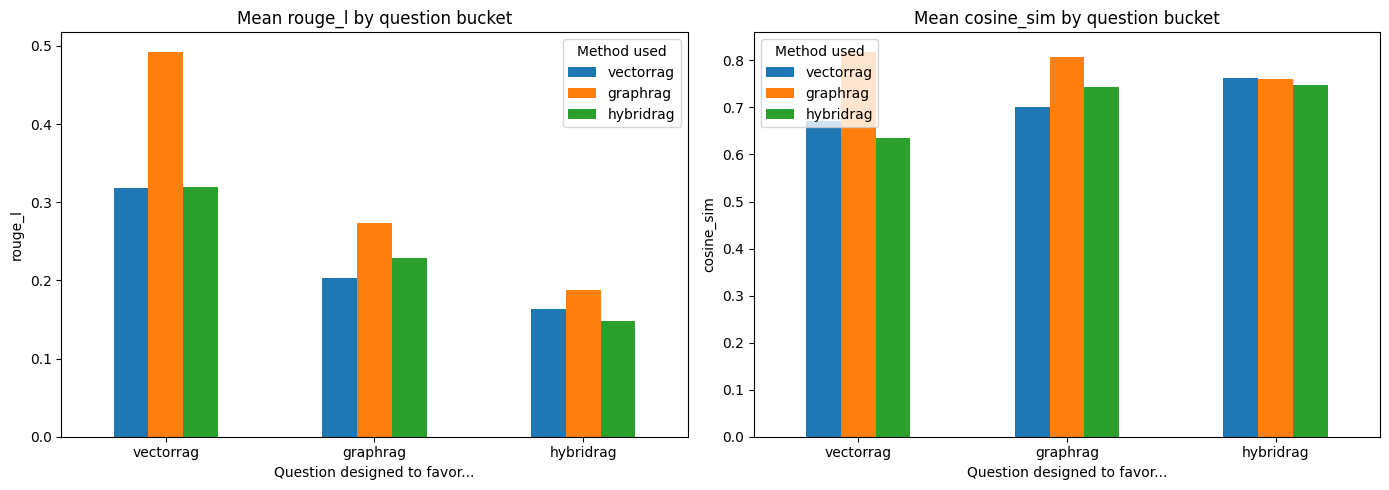

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric in zip(axes, ["rouge_l", "cosine_sim"]):
    pivot = results_df.pivot_table(index="designed_to_favor", columns="method", values=metric, aggfunc="mean")
    pivot = pivot.reindex(["vectorrag", "graphrag", "hybridrag"], axis=1)
    pivot = pivot.reindex(["vectorrag", "graphrag", "hybridrag"], axis=0)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Mean {metric} by question bucket")
    ax.set_xlabel("Question designed to favor...")
    ax.set_ylabel(metric)
    ax.legend(title="Method used")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
fig_path = ARTIFACTS_DIR / "ablation_results.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved -> {fig_path.resolve()}")
plt.show()


In [16]:
results_csv_path = ARTIFACTS_DIR / "ablation_results.csv"
results_df.to_csv(results_csv_path, index=False)
print(f"Saved full per-question results -> {results_csv_path.resolve()}")


Saved full per-question results -> /teamspace/studios/this_studio/AlzRAGBench/artifacts/ablation_results.csv


## 4.13 Discussion and limitations

Read the bar charts above as: for each cluster of bars (one cluster per question
bucket), does the bar matching that bucket's own method (e.g. the "graphrag" bar
within the "graphrag" bucket cluster) come out on top? If so, the eval set's design
hypothesis is confirmed for that bucket; if not, that's a genuinely interesting
finding worth digging into (a question we predicted would favor GraphRAG might have
been answerable from a single Wikipedia chunk after all, for instance) -- **not
evidence the dataset or notebook is broken.**

**Limitations to keep in mind when interpreting these results:**

- **30 questions is a small eval set.** Differences of a few percentage points in mean
  ROUGE-L/cosine-similarity between methods are not statistically robust conclusions --
  treat this as a demonstration of the *evaluation methodology*, not a definitive
  verdict on VectorRAG vs. GraphRAG vs. HybridRAG in general.
- **Automatic metrics are imperfect proxies for correctness.** ROUGE-L rewards
  wording overlap, not factual accuracy; embedding cosine similarity rewards semantic
  closeness, which a confidently wrong but topically-related answer can still score
  well on. Neither metric can catch subtle factual errors the way a human reviewer or
  a well-designed LLM-as-judge rubric could.
- **The gold `expected_answer` values were LLM-synthesized during dataset
  construction**, grounded in the source corpus but not independently expert-verified
  -- see `../Dataset/README.md` for this caveat in full.
- **Reduced `max_gen_len`** (Section 4.6, lowered from Notebooks 2-3's demo defaults
  to keep 90 generations tractable) trades some answer quality for runtime -- raise it
  and re-run if generation quality looks low across the board rather than only for one
  method (which would suggest a genuine method weakness instead of a compute-budget
  artifact). No quantization is used in this version (SDLM-3B is small enough to run
  in plain bf16), so quantization noise is no longer a confound here the way it may
  have been with the previous 4-bit 8B-model version.
- **The retrieval-quality diagnostics** (`vector_hit_rate`, `graph_hit_rate`) only
  apply to VectorRAG's/GraphRAG's own retrieved material -- for HybridRAG we did not
  separately track which half (vector or graph) the final answer actually drew on,
  so a low HybridRAG hit-rate on one side doesn't necessarily mean HybridRAG failed,
  if it successfully relied on the other side instead.

This concludes the AlzRAGBench notebook series: Notebook 1 built and visualized the
knowledge graph, Notebook 2 built GraphRAG and demonstrated four retrieval strategies,
Notebook 3 built VectorRAG over the chunked corpus, and this notebook combined both
into HybridRAG and ran the full ablation comparison.